# ANN benchmark 

In [11]:
# install 
%pip install numpy tensorflow matplotlib pandas seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# imports

import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
import matplotlib.pyplot as plt

In [2]:
# hyper paramaters

BATCH_SIZE = 30024
EPOCHS = 10
VERBOSE = 1
OPTIMIZER = Adam(0.0005)
NB_CLASSES = 1

2025-03-26 10:48:46.495951: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2025-03-26 10:48:46.495976: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-03-26 10:48:46.495981: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1742986126.495991  228087 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1742986126.496008  228087 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Model defintion:

In [3]:
def create_model(input_shape):
    model = Sequential([
        layers.Dense(512, input_shape=(input_shape,)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(512),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64),
        layers.BatchNormalization(),
        
        layers.Dense(NB_CLASSES, activation='sigmoid')
    ])

    return model

# Load datasets

In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


df_chall = pd.read_csv('../datasets/challenger_dataset.csv')
df_grandMaster = pd.read_csv('../datasets/grandmaster_dataset.csv')
df_master = pd.read_csv('../datasets/master_dataset.csv')

df = pd.concat([df_chall, df_grandMaster, df_master])

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

temp = df["timestamp"]
df.drop(columns=["timestamp"], inplace=True)
df.fillna(df.median(), inplace=True)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

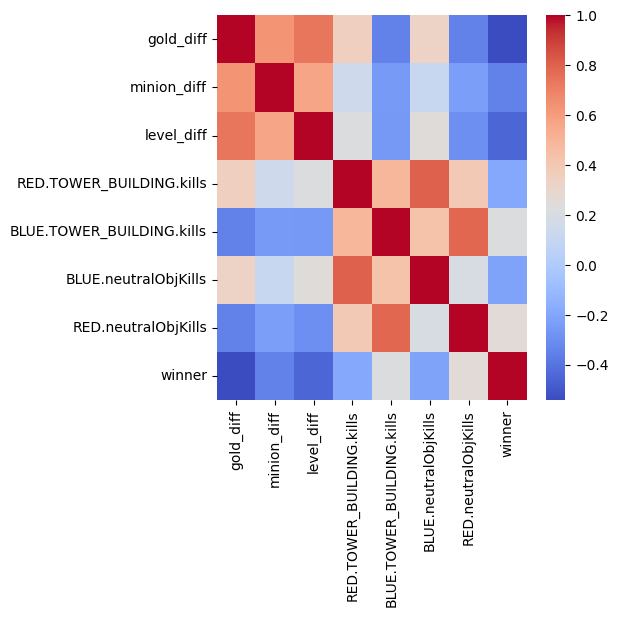

In [5]:
#trying to modify the dataset 
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']
# tdf["timestamp"] = temp

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [6]:
# split the dataset into training and testing
from sklearn.model_selection import train_test_split

X = tdf.drop('winner', axis=1)
y = tdf['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4840955, 7) (1210239, 7) (4840955,) (1210239,)


# Train the model

In [12]:
# create the model
model = create_model(len(X.columns))
model.compile(optimizer=OPTIMIZER, loss='binary_crossentropy', metrics=["accuracy"])
model.summary()

/Users/simonbandiera/Documents/kent/AiSysImplementation/LeagueOfLegendsModelBenchmark/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/simonbandiera/Documents/kent/AiSysImplementation/LeagueOfLegendsModelBenchmark/.venv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,278,213 (12.51 MB)

 Trainable params: 1,091,329 (4.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

 Optimizer params: 2,182,660 (8.33 MB)

In [13]:
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

# train the model
history = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=VERBOSE, validation_split=0.2)

# evaluate the model
score = model.evaluate(X_test, y_test, verbose=VERBOSE)
print("Test score:", score[0])
print("Test accuracy:", score[1])

y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

Epoch 1/10


NotImplementedError: numpy() is only available when eager execution is enabled.

In [ ]:
# f1 score
f1 = f1_score(y_test, y_pred)
print("F1 score:", f1)

# recall
recall = recall_score(y_test, y_pred)
print("Recall score:", recall)

# AUC-Roc
roc = roc_auc_score(y_test, y_pred)
print("AUC-ROC score:", roc)


F1 score: 0.7327156828966734
Recall score: 0.716447954297236
AUC-ROC score: 0.7425260862742893


6719/6719 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.5163 - loss: 0.6932
5926/5926 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.5272 - loss: 0.6926
4578/4578 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.5610 - loss: 0.6823
5059/5059 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.6025 - loss: 0.6623
5921/5921 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.6260 - loss: 0.6446
6428/6428 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.6441 - loss: 0.6317
6794/6794 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.6639 - loss: 0.6131
6979/6979 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.6805 - loss: 0.5935
7088/7088 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.6952 - loss: 0.5756
7147/7147 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.7099 - loss: 0.5581
7177/7177 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.7229 - loss: 0.5402
7191/7191 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.7383 - loss: 0.5212
7199/7199 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.7526 -

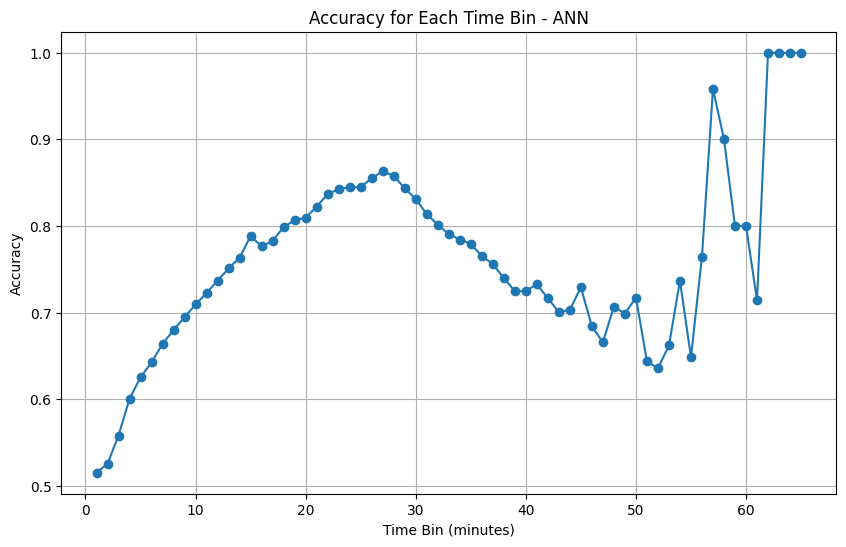

In [ ]:
tdf["time_bin"] = (temp // 60000) * 60000

def predict_ann(model, X_test, y_test):
    pred = model.evaluate(X_test, y_test)
    return pred[1]

def plot_accuracy_over_time(model, label, df, prediction):
    minutes = []
    accuracies = []
    for time_bin, df_bin in df.groupby("time_bin"):
        minutes.append(time_bin // 60000)
        X_test_bin = df_bin.drop(columns=["winner", "time_bin"])
        y_test_bin = df_bin["winner"]
        accuracies.append(prediction(model, X_test_bin, y_test_bin))

    plt.figure(figsize=(10, 6))
    plt.plot(minutes, accuracies, marker='o', linestyle='-')
    plt.title(f'Accuracy for Each Time Bin - {label}')
    plt.xlabel('Time Bin (minutes)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

plot_accuracy_over_time(model, "ANN", tdf, predict_ann)

we can see that the accuracy greatly varies depending on the state of the game, which allow us to make some conclusion:
- first, the first 2 minutes have a close to random accuracy because it's in this range that remaking a game is still possible, making the dataset "poluted" with this game and also because, obviously, the first few minutes of a lol games aren't decisive on it's outcome
- then we can see the accuracy slowly increasing until the 30th minutes, were most games end. This is pretty logical since the difference between the two teams is, in most game, only getting bigger which make the team winning get an even bigger advantage with drakes, barons tower, and so on.
- after that we can see the accuracy of our model disminishin, this is because around this time, the team that is ahead is likely full stuff and max level, meaning they can't get any stronger, and that the loosing team is catching.

after the 40 minutes, the data is irelevant because of the amount of games being to small to not be overfitted

We can also see an outlier around the 14th minute, this is probably due to the herald spawning getting and great advantage especially if the void grubs are killed by the same team before, it gives a big gold lead by allowing the team killing it to get one, two or more tower early in the game giving them map control and economy.